In [2]:
import pandas as pd
orders=pd.read_csv("C:/Users/Asus/AppData/Local/GitHubDesktop/Shopsense/data/raw/olist_orders_dataset.csv")
customers = pd.read_csv('C:/Users/Asus/AppData/Local/GitHubDesktop/Shopsense/data/raw/olist_customers_dataset.csv')
order_items = pd.read_csv('C:/Users/Asus/AppData/Local/GitHubDesktop/Shopsense/data/raw/olist_order_items_dataset.csv')
payments = pd.read_csv('C:/Users/Asus/AppData/Local/GitHubDesktop/Shopsense/data/raw/olist_order_payments_dataset.csv')
reviews = pd.read_csv('C:/Users/Asus/AppData/Local/GitHubDesktop/Shopsense/data/raw/olist_order_reviews_dataset.csv')
products = pd.read_csv('C:/Users/Asus/AppData/Local/GitHubDesktop/Shopsense/data/raw/olist_products_dataset.csv')
category_translation = pd.read_csv('C:/Users/Asus/AppData/Local/GitHubDesktop/Shopsense/data/raw/product_category_name_translation.csv')


In [4]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [3]:
# Start with orders as the base table
df=orders.merge(customers,on='customer_id',how='left')
print('After merging customers:',df.shape)

df=df.merge(order_items,on='order_id',how='left')
print('After merging order_items:',df.shape)

df=df.merge(payments,on='order_id',how='left')
print('After merging payments:',df.shape)

df=df.merge(products,on='product_id',how='left')
print('After merging products:',df.shape)

df=df.merge(category_translation,on='product_category_name',how='left')
print('After merging category translation:',df.shape)

After merging customers: (99441, 12)
After merging order_items: (113425, 18)
After merging payments: (118434, 22)
After merging products: (118434, 30)
After merging category translation: (118434, 31)


In [5]:
reviews_summary=reviews[['order_id','review_score','review_comment_message']]
df=df.merge(reviews,on='order_id',how='left')
print('After merging reviews:',df.shape)

After merging reviews: (119143, 37)


In [6]:
date_cols = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_carrier_date', 'order_delivered_customer_date', 
             'order_estimated_delivery_date']
for col in date_cols:
    df[col]=pd.to_datetime(df[col])

In [7]:
#delivery time
df['delivery_days']=(df['order_delivered_customer_date']- df['order_purchase_timestamp']).dt.days
df['delivery_days'].describe()

count    115722.000000
mean         12.022589
std           9.454922
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_days, dtype: float64

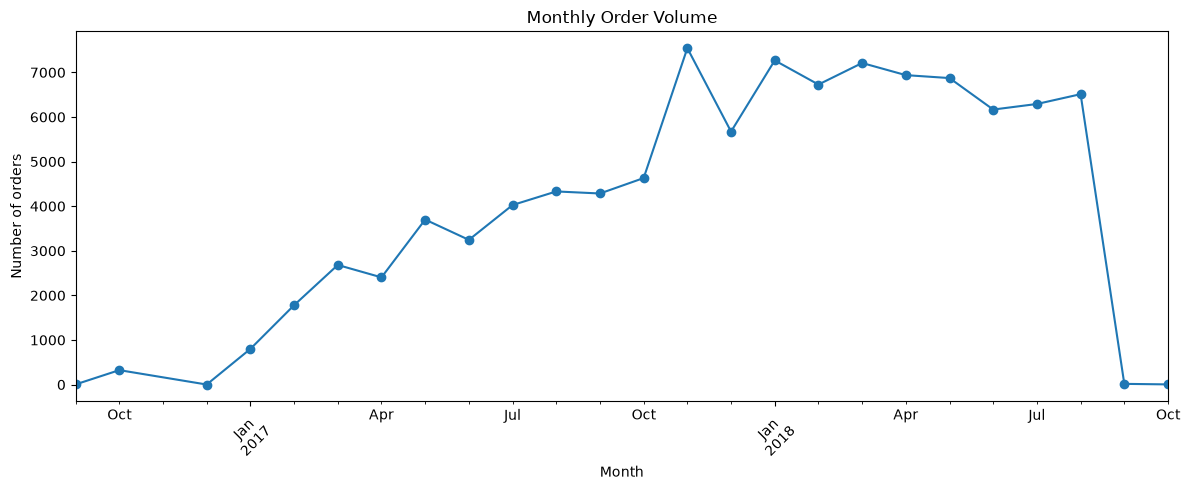

In [8]:
#monthly order volumes
import matplotlib.pyplot as plt
import seaborn as sns

df['order_month']=df['order_purchase_timestamp'].dt.to_period('M')
monthly_orders=df.groupby('order_month')['order_id'].nunique()

plt.figure(figsize=(12,5))
monthly_orders.plot(kind='line',marker='o')
plt.title('Monthly Order Volume')
plt.ylabel('Number of orders')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

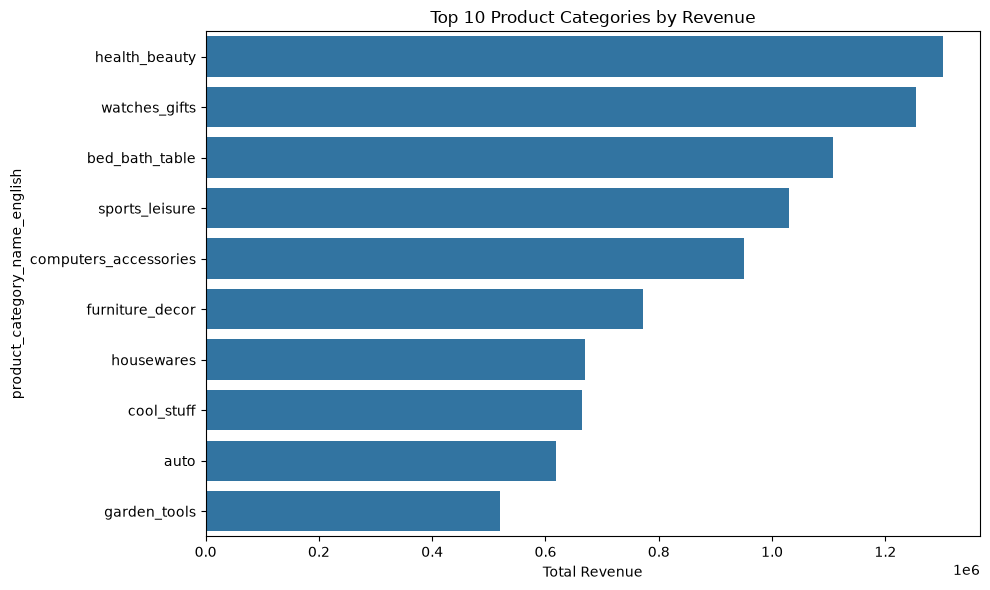

In [11]:
#Top product categories by sales:
top_categories=df.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_categories.values, y=top_categories.index)
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Total Revenue')
plt.tight_layout()
plt.show()

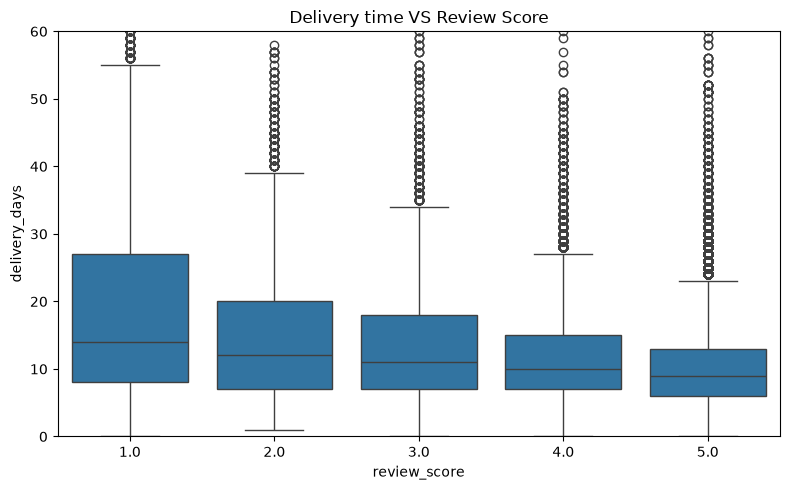

In [12]:
#Does delivery time affect review score?
plt.figure(figsize=(8,5))
sns.boxplot(x='review_score',y='delivery_days',data=df)
plt.title('Delivery time VS Review Score')
plt.ylim(0,60) #exclude extreme outliers for readability
plt.tight_layout()
plt.show()

In [13]:
df.to_csv('C:/Users/Asus/AppData/Local/GitHubDesktop/Shopsense/data/processed/merged_orders.csv',index=False)